# Import Library
In this step I will add Library that has to be used for Lab3

In [599]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

precision = precision_score(y_test_c, y_pred_c)
recall = recall_score(y_test_c, y_pred_c)
f1 = f1_score(y_test_c, y_pred_c)

# Load Dataset
Import Dataset from url:https://www.kaggle.com/datasets/mirichoi0218/insurance

In [600]:
df = pd.read_csv("insurance.csv")

print(df.head())

le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])
df['smoker'] = le.fit_transform(df['smoker'])
df['region'] = le.fit_transform(df['region'])

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


# Dataset Overview
I will validate data before coding 


In [601]:
print("Shape :", df.shape)

print("\nInformation :")
df.info()

print("\nMissing Value :")
print(df.isnull().sum())

print("\nStatistics :")
display(df.describe())

Shape : (1338, 7)

Information :
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   int64  
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   int64  
 5   region    1338 non-null   int64  
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(5)
memory usage: 73.3 KB

Missing Value :
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Statistics :


,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,0.505232,30.663397,1.094918,0.204783,1.515695,13270.422265
std,14.049960,0.500160,6.098187,1.205493,0.403694,1.104885,12110.011237
min,18.000000,0.000000,15.960000,0.000000,0.000000,0.000000,1121.873900
25%,27.000000,0.000000,26.296250,0.000000,0.000000,1.000000,4740.287150
50%,39.000000,1.000000,30.400000,1.000000,0.000000,2.000000,9382.033000
75%,51.000000,1.000000,34.693750,2.000000,0.000000,2.000000,16639.912515
max,64.000000,1.000000,53.130000,5.000000,1.000000,3.000000,63770.428010


# Data Exploration
inspect overview of Dataset 

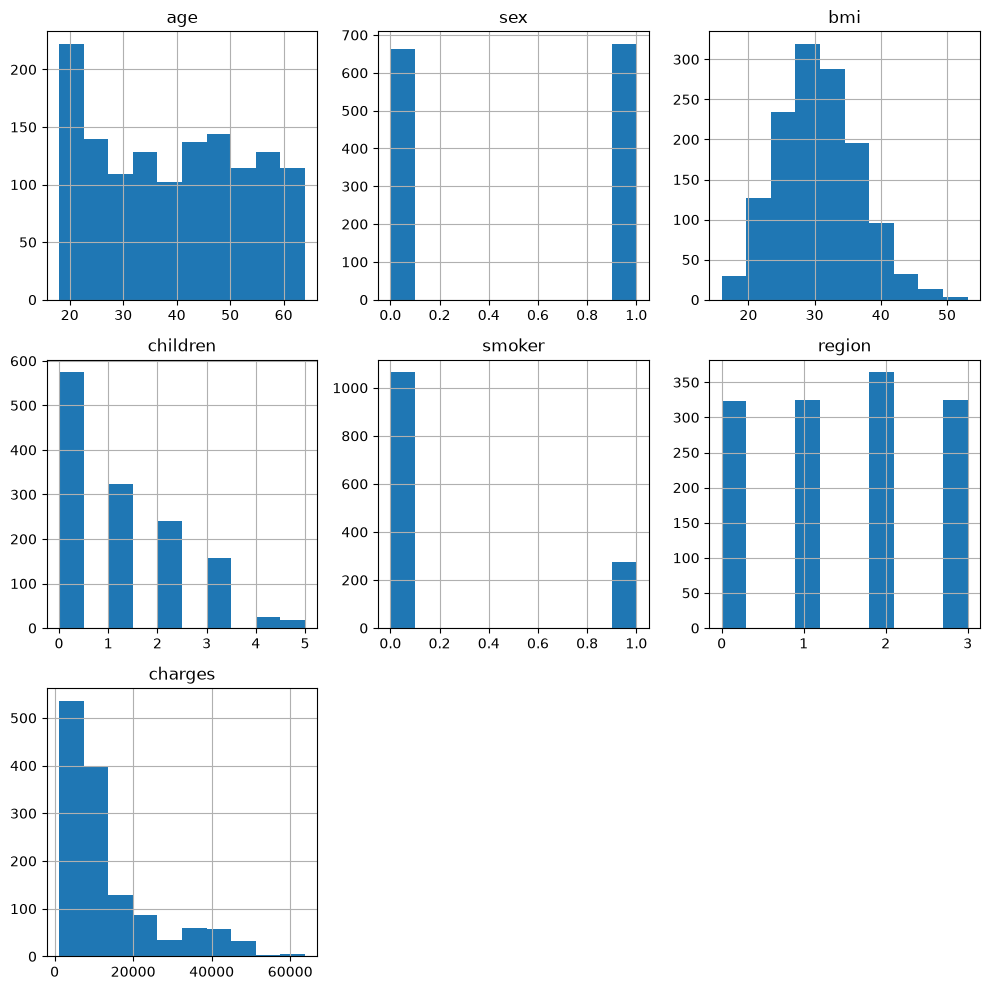

In [602]:
df.hist(figsize=(10,10))
plt.tight_layout()

plt.show()

# LAB 1 : Regression
- Simple Linear Regression  
- Multiple Linear Regression  
- Age Prediction

# Simple Linear Regression 

Use only one feature to prediction

In [603]:
X_simple = df[["charges"]]
y_reg = df["age"]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple,
    y_reg,
    test_size=0.2,
    random_state=42
)

In [604]:
model_simple = LinearRegression()
model_simple.fit(X_train_s, y_train_s)
y_pred_simple = model_simple.predict(X_test_s)

## Evaluation of  Simple Linear Regression

In [605]:
mae = mean_absolute_error(y_test_s, y_pred_simple)
rmse = np.sqrt(mean_squared_error(y_test_s, y_pred_simple))
r2 = r2_score(y_test_s, y_pred_simple)

print("Simple Linear Regression")
print("MAE :", round(mae,3))
print("RMSE :", round(rmse,3))
print("R² :", round(r2,3))

Simple Linear Regression
MAE : 11.329
RMSE : 13.025
R² : 0.127


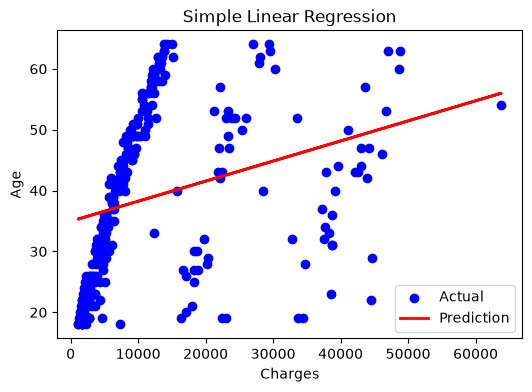

In [606]:
plt.figure(figsize=(6,4))
plt.scatter(X_test_s, y_test_s, color="blue", label="Actual")
plt.plot(X_test_s, y_pred_simple, color="red", linewidth=2, label="Prediction")
plt.xlabel("Charges")
plt.ylabel("Age")
plt.title("Simple Linear Regression")
plt.legend()
plt.show()

# Multiple Linear Regression

Use a lot of Features to prediction

In [607]:
X_multi = df.drop("age", axis=1)
y_reg = df["age"]

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi,
    y_reg,
    test_size=0.2,
    random_state=42
)

In [608]:
model_multiple = LinearRegression()
model_multiple.fit(X_train_m, y_train_m)
y_pred_multiple = model_multiple.predict(X_test_m)

## Evaluation of Multiple Linear Regression

In [609]:
mae2 = mean_absolute_error(y_test_m, y_pred_multiple)
rmse2 = np.sqrt(mean_squared_error(y_test_m, y_pred_multiple))
r22 = r2_score(y_test_m, y_pred_multiple)

print("Multiple Linear Regression")
print("MAE :", round(mae2,3))
print("RMSE :", round(rmse2,3))
print("R² :", round(r22,3))

Multiple Linear Regression
MAE : 10.0
RMSE : 11.926
R² : 0.268


In [610]:
result = pd.DataFrame({
    "Actual": y_test_m.values,
    "Predicted": y_pred_multiple
})

result.head()

,Actual,Predicted
0,45,40.709892
1,36,36.319278
2,64,35.784321
3,46,41.079989
4,19,39.391907


## Comparison Simple and Multiple Linear Regression

In [611]:
compare = pd.DataFrame({
    "Model": [
        "Simple Linear Regression",
        "Multiple Linear Regression"
    ],
    "MAE": [mae, mae2],
    "RMSE": [rmse, rmse2],
    "R²": [r2, r22]
})

compare

,Model,MAE,RMSE,R²
0,Simple Linear Regression,11.328926,13.025334,0.126641
1,Multiple Linear Regression,10.000111,11.925843,0.267861


# LAB 2 : Classification

Inspect the label to identify the data type and predict the target classes

- Preparing Classification Data  
- Decision Boundary Visualization
- Logistic Regression  
- Gender Prediction  
- Confusion Matrix  

## Preparing Classification Data
define class of data before coding

In [612]:
df["gender_label"] = df["sex"]

df[["sex", "gender_label"]].head()

,sex,gender_label
0,0,0
1,1,1
2,1,1
3,1,1
4,1,1


## Feature and Target

In [613]:
X_clf = df.drop(["sex", "gender_label"], axis=1)
y_clf = df["gender_label"]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf,
    y_clf,
    test_size=0.2,
    random_state=42
)

## Feature Scaling
Adjust scale of data make model easier to learning

In [614]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_c)
X_test_scaled = scaler.transform(X_test_c)

## Principal Component Analysis (PCA)

In [615]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(X_train_pca.shape)

(1070, 2)


## Logistic Regression

In [616]:
model_logreg = LogisticRegression(random_state=42)
model_logreg.fit(X_train_pca, y_train_c)
y_pred_c = model_logreg.predict(X_test_pca)

## Accuracy

In [617]:
acc = accuracy_score(y_test_c, y_pred_c)
print("Accuracy :", round(acc,3))

Accuracy : 0.481


## Confusion Matrix

In [618]:
cm = confusion_matrix(y_test_c, y_pred_c)
print(cm)

[[76 64]
 [75 53]]


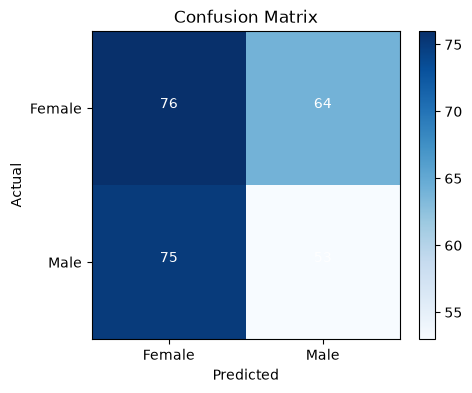

In [619]:
plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0,1], ["Female", "Male"])
plt.yticks([0,1], ["Female", "Male"])
plt.xlabel("Predicted")
plt.ylabel("Actual")

# เพิ่มตัวเลขลงในช่อง
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")

plt.show()

## Classification Report

In [620]:
print(classification_report(y_test_c, y_pred_c, target_names=["Female", "Male"]))

              precision    recall  f1-score   support

      Female       0.50      0.54      0.52       140
        Male       0.45      0.41      0.43       128

    accuracy                           0.48       268
   macro avg       0.48      0.48      0.48       268
weighted avg       0.48      0.48      0.48       268



## ROC Curve
Classification Evaluation for Each Model
if AUC is 1.0 it mean model has great performance

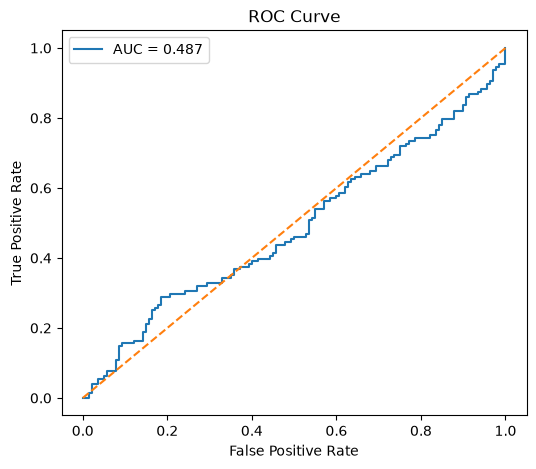

In [621]:
y_prob = model_logreg.predict_proba(X_test_pca)[:,1]
fpr, tpr, _ = roc_curve(y_test_c, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Decision Boundary Visualization
Separates the feature space to classify the data

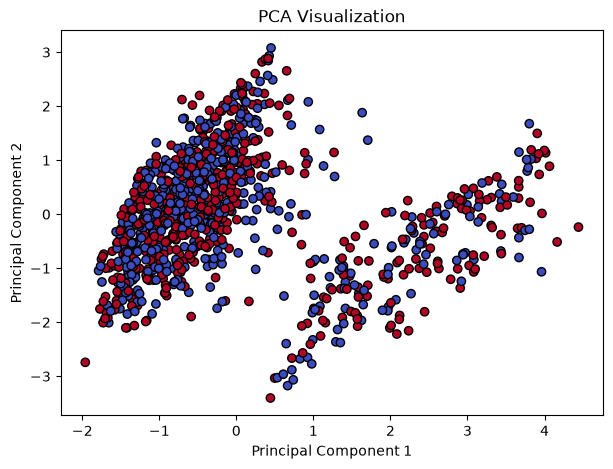

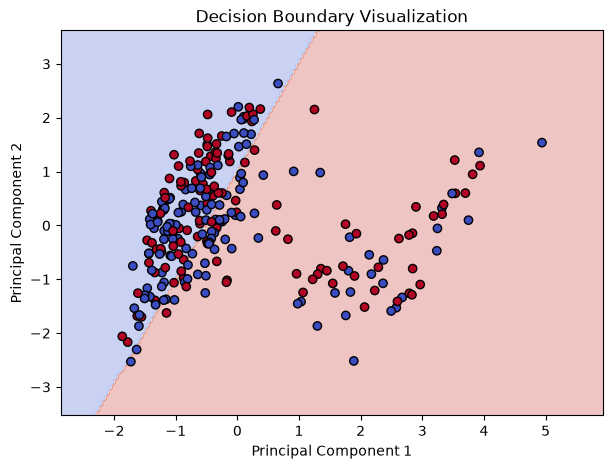

In [622]:
plt.figure(figsize=(7,5))
plt.scatter(
    X_train_pca[:,0],
    X_train_pca[:,1],
    c=y_train_c,
    cmap="coolwarm",
    edgecolors='k'
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization")
plt.show()

# พล็อตพื้นที่ Decision Boundary
x_min, x_max = X_test_pca[:, 0].min() - 1, X_test_pca[:, 0].max() + 1
y_min, y_max = X_test_pca[:, 1].min() - 1, X_test_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

Z = model_logreg.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(7,5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test_c, cmap="coolwarm", edgecolors='k')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Decision Boundary Visualization")
plt.show()

# LAB 3 : Model Comparison

Comparison performance of Regression and Classification

- Simple Vs Multiple Linear Regression  
- Training vs Testing Performance  
- Regression vs Classification  
- Model Performance Metrics  

## Simple Vs Multiple Linear Regression

comparing Simple Linear Regression and Multiple Linear Regression

In [623]:
comparison_regression = pd.DataFrame({
    "Model": [
        "Simple Linear Regression",
        "Multiple Linear Regression"
    ],
    "MAE": [mae, mae2],
    "RMSE": [rmse, rmse2],
    "R² Score": [r2, r22]
})

comparison_regression

,Model,MAE,RMSE,R² Score
0,Simple Linear Regression,11.328926,13.025334,0.126641
1,Multiple Linear Regression,10.000111,11.925843,0.267861


## Training vs Testing Performance

In [624]:
train_score = model_multiple.score(X_train_m, y_train_m)
test_score = model_multiple.score(X_test_m, y_test_m)

print("Training Score :", round(train_score,3))
print("Testing Score :", round(test_score,3))

Training Score : 0.271
Testing Score : 0.268


## Regression vs Classification

Comparison performance of Regression and Classification

In [625]:
print("Regression")
print("MAE :", round(mae2,3))
print("RMSE :", round(rmse2,3))
print("R² :", round(r22,3))

print("\nClassification")
print("Accuracy :", round(acc,3))
print("Precision :", round(precision, 3))
print("Recall :", round(recall, 3))
print("F1-score :", round(f1, 3))


Regression
MAE : 10.0
RMSE : 11.926
R² : 0.268

Classification
Accuracy : 0.481
Precision : 0.453
Recall : 0.414
F1-score : 0.433


## Model Performance Metrics

Summary for each Model

In [626]:
summary = pd.DataFrame({
    "Model":[
        "Simple Regression",
        "Multiple Regression",
        "Logistic Regression"
    ],
    "MAE":[
        round(mae,3),
        round(mae2,3),
        "-"
    ],
    "RMSE":[
        round(rmse,3),
        round(rmse2,3),
        "-"
    ],
    "R²":[
        round(r2,3),
        round(r22,3),
        "-"
    ],
    "Accuracy":[
        "-",
        "-",
        round(acc,3)
    ]
})

summary

,Model,MAE,RMSE,R²,Accuracy
0,Simple Regression,11.329,13.025,0.127,-
1,Multiple Regression,10.0,11.926,0.268,-
2,Logistic Regression,-,-,-,0.481
